In [1]:
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

# Shared config (run this cell first; every chapter below relies only on it).
# Banks to exclude so only non-financial entities remain, plus the currency groups.
banks = "'7LTWFZYICNSX8D621K86', 'R0MUWSFPU8MPRO8K5P83', 'K8MS7FD7N5Z2WQ51AZ71', '5493006QMFDDMYWIAM13', '529900ODI3047E2LIV03'"
asian = "'JPY', 'CNY', 'CNH', 'HKD', 'SGD', 'KRW', 'TWD', 'INR', 'THB', 'IDR', 'MYR', 'PHP', 'PKR', 'VND', 'BDT', 'LKR', 'KZT', 'UZS'"
north_american = "'USD', 'CAD', 'MXN'"
european = "'GBP', 'CHF', 'SEK', 'NOK', 'DKK', 'PLN', 'CZK', 'HUF', 'RON', 'BGN', 'HRK', 'RSD', 'ISK', 'UAH'"

## Outstanding time series

In [152]:
query = f"""

WITH legs AS (
    -- entity is buyer = receiver of currency1 (ESMA REFIT GL §435: leg-1 TAKE), so long currency1
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'long' ELSE 'short' END AS direction
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND buyer_nfc = 1
      AND buyer_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
    UNION ALL
    -- entity is seller = payer of currency1 (leg-1 MAKE), so short currency1
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'short' ELSE 'long' END AS direction
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND seller_nfc = 1
      AND seller_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
)
SELECT
    reference_period,
    SUM(CASE WHEN direction = 'long'  THEN notional_eur ELSE 0 END) AS long_eur,
    SUM(CASE WHEN direction = 'short' THEN notional_eur ELSE 0 END) AS short_eur
FROM legs
GROUP BY reference_period
ORDER BY reference_period

"""

ts = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_16344\4076457925.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ts = pd.read_sql_query(query, cnxn)


In [153]:
ts = ts[(ts['long_eur'] > 70000000000) & (ts['short_eur'] > 130000000000)]

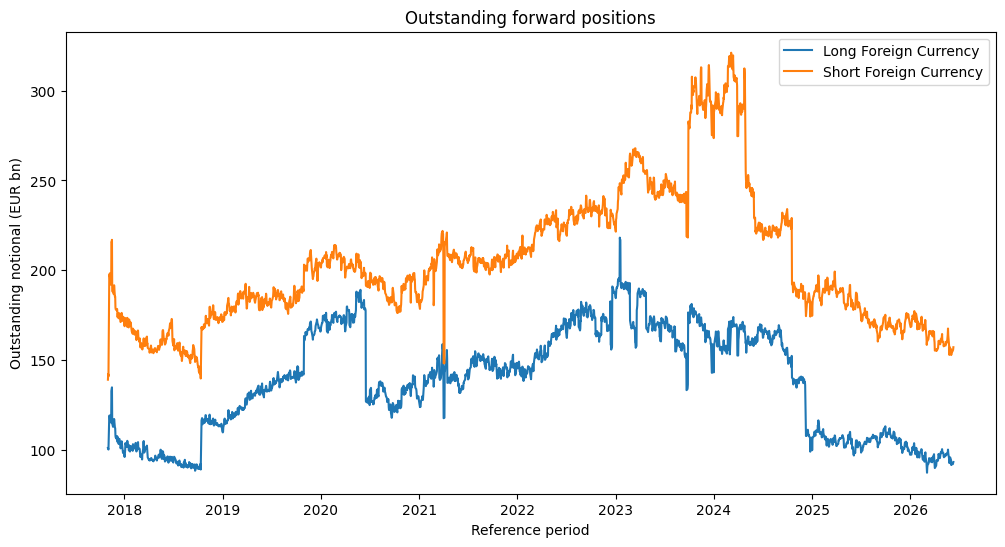

In [154]:
ts['reference_period'] = pd.to_datetime(ts['reference_period'])
ts = ts.set_index('reference_period').sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ts.index, ts['long_eur'] / 1e9, label='Long Foreign Currency')
ax.plot(ts.index, ts['short_eur'] / 1e9, label='Short Foreign Currency')
ax.set_xlabel('Reference period')
ax.set_ylabel('Outstanding notional (EUR bn)')
ax.set_title('Outstanding forward positions')
ax.legend()
plt.show()

In [182]:
# USD only: same as above but restricted to EUR/USD pairs (long/short = long/short USD)
query = f"""

WITH legs AS (
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'long' ELSE 'short' END AS direction
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND buyer_nfc = 1
      AND buyer_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND (currency1 = 'USD' OR currency2 = 'USD')
    UNION ALL
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'short' ELSE 'long' END AS direction
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND seller_nfc = 1
      AND seller_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND (currency1 = 'USD' OR currency2 = 'USD')
)
SELECT
    reference_period,
    SUM(CASE WHEN direction = 'long'  THEN notional_eur ELSE 0 END) AS long_eur,
    SUM(CASE WHEN direction = 'short' THEN notional_eur ELSE 0 END) AS short_eur
FROM legs
WHERE reference_period <= '2026-04-01'
GROUP BY reference_period
ORDER BY reference_period

"""

ts_usd = pd.read_sql_query(query, cnxn)

# Rows in the middle window stay untouched no matter what
in_middle = (ts_usd['reference_period'] >= '2022-01-01') & (ts_usd['reference_period'] < '2025-01-01')

# The size test you want to apply at the edges (before 2022 and after 2025)
big_enough = (ts_usd['long_eur'] > 30_000_000_000) & (ts_usd['short_eur'] > 43_000_000_000)

# Keep a row if it's in the middle, OR it's outside the middle and passes the test
ts_usd = ts_usd[in_middle | big_enough]
ts_usd['reference_period'] = pd.to_datetime(ts_usd['reference_period'])
ts_usd = ts_usd.set_index('reference_period').sort_index()

C:\Users\hermesf\AppData\Local\Temp\ipykernel_16344\347029106.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ts_usd = pd.read_sql_query(query, cnxn)


In [183]:
event = pd.Timestamp('2025-04-02')  # Liberation Day tariff announcement

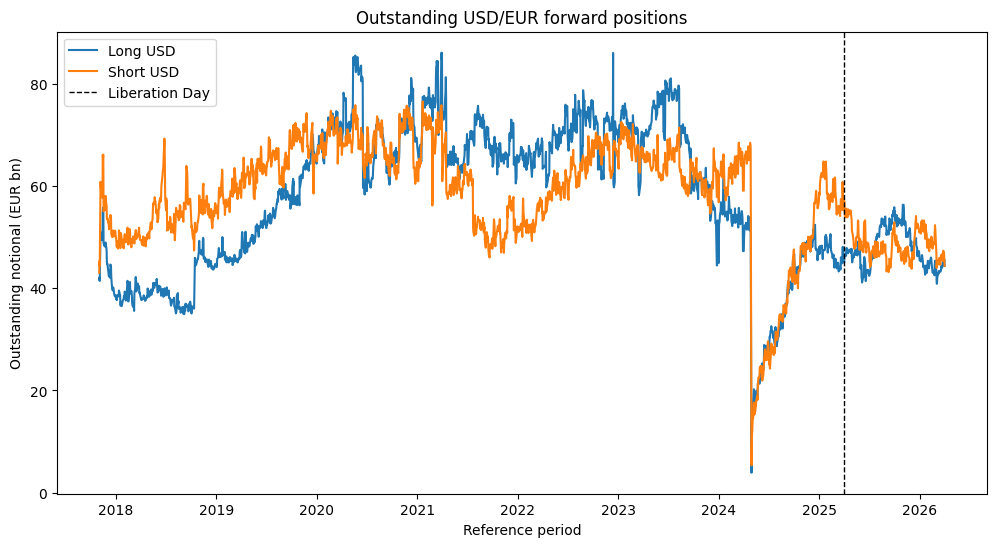

In [184]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ts_usd.index, ts_usd['long_eur'] / 1e9, label='Long USD')
ax.plot(ts_usd.index, ts_usd['short_eur'] / 1e9, label='Short USD')
ax.axvline(event, color='black', linestyle='--', linewidth=1, label='Liberation Day')
ax.set_xlabel('Reference period')
ax.set_ylabel('Outstanding notional (EUR bn)')
ax.set_title('Outstanding USD/EUR forward positions')
ax.legend()
plt.show()

## Currency comparison

In [102]:
query = f"""

WITH legs AS (
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'long' ELSE 'short' END AS direction,
           CASE WHEN currency1 = 'EUR' THEN currency2 ELSE currency1 END AS foreign_ccy
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND buyer_nfc = 1
      AND buyer_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
    UNION ALL
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'short' ELSE 'long' END AS direction,
           CASE WHEN currency1 = 'EUR' THEN currency2 ELSE currency1 END AS foreign_ccy
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND seller_nfc = 1
      AND seller_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
),
classified AS (
    SELECT reference_period, notional_eur, direction,
           CASE WHEN foreign_ccy IN ({asian})          THEN 'Asia'
                WHEN foreign_ccy IN ({north_american})  THEN 'North America'
                WHEN foreign_ccy IN ({european})        THEN 'Europe'
                ELSE 'Other' END AS region
    FROM legs
),
n AS (SELECT COUNT(DISTINCT reference_period) AS n_periods FROM classified)
-- average outstanding notional per reporting date, by region and direction
SELECT region, direction, SUM(notional_eur) / MAX(n_periods) AS avg_eur
FROM classified CROSS JOIN n
GROUP BY region, direction
ORDER BY region, direction

"""

reg = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_16344\1489804444.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  reg = pd.read_sql_query(query, cnxn)


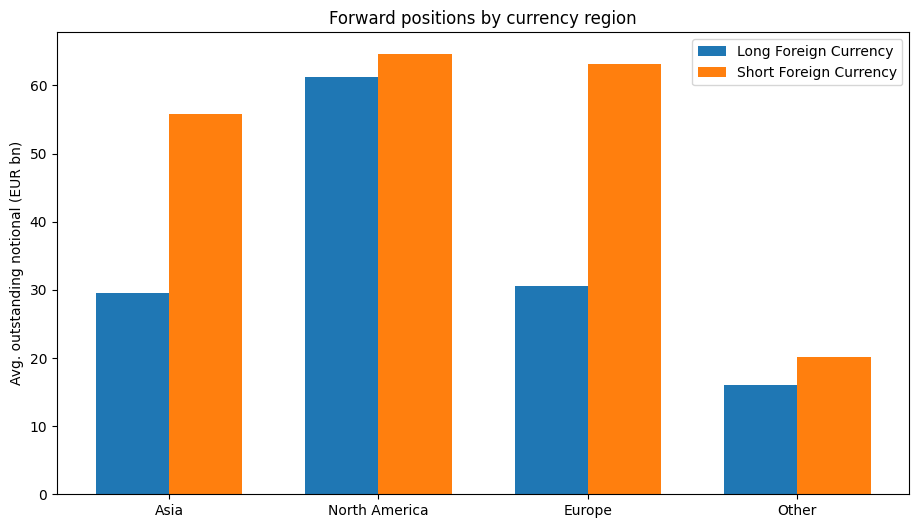

In [103]:
regions = ['Asia', 'North America', 'Europe', 'Other']
piv = (reg.pivot(index='region', columns='direction', values='avg_eur')
          .reindex(index=regions, columns=['long', 'short'], fill_value=0))

x = np.arange(len(regions))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w / 2, piv['long'] / 1e9, w, label='Long Foreign Currency')
ax.bar(x + w / 2, piv['short'] / 1e9, w, label='Short Foreign Currency')
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel('Avg. outstanding notional (EUR bn)')
ax.set_title('Forward positions by currency region')
ax.legend()
plt.show()

## Liberation Day

In [185]:
start = '2024-04-26'  # REFIT period only (exclude the pre-2019 EMIR snapshots)

query = f"""

WITH legs AS (
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'long' ELSE 'short' END AS direction,
           CASE WHEN currency1 = 'EUR' THEN currency2 ELSE currency1 END AS foreign_ccy
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND buyer_nfc = 1
      AND buyer_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND reference_period >= '{start}'
      AND reference_period NOT IN ('2025-04-18', '2025-04-21')
    UNION ALL
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'short' ELSE 'long' END AS direction,
           CASE WHEN currency1 = 'EUR' THEN currency2 ELSE currency1 END AS foreign_ccy
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND seller_nfc = 1
      AND seller_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND reference_period >= '{start}'
      AND reference_period NOT IN ('2025-04-18', '2025-04-21')
),
classified AS (
    SELECT reference_period, notional_eur, direction,
           CASE WHEN foreign_ccy = 'USD'        THEN 'USD'
                WHEN foreign_ccy IN ({asian})    THEN 'Asia'
                WHEN foreign_ccy IN ({european}) THEN 'Europe' END AS grp
    FROM legs
)
-- net (long - short) outstanding notional per day and group
SELECT reference_period, grp,
       SUM(CASE WHEN direction = 'long' THEN notional_eur ELSE -notional_eur END) AS net_eur
FROM classified
WHERE grp IS NOT NULL
GROUP BY reference_period, grp
ORDER BY reference_period, grp

"""

es = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_16344\3836242845.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  es = pd.read_sql_query(query, cnxn)


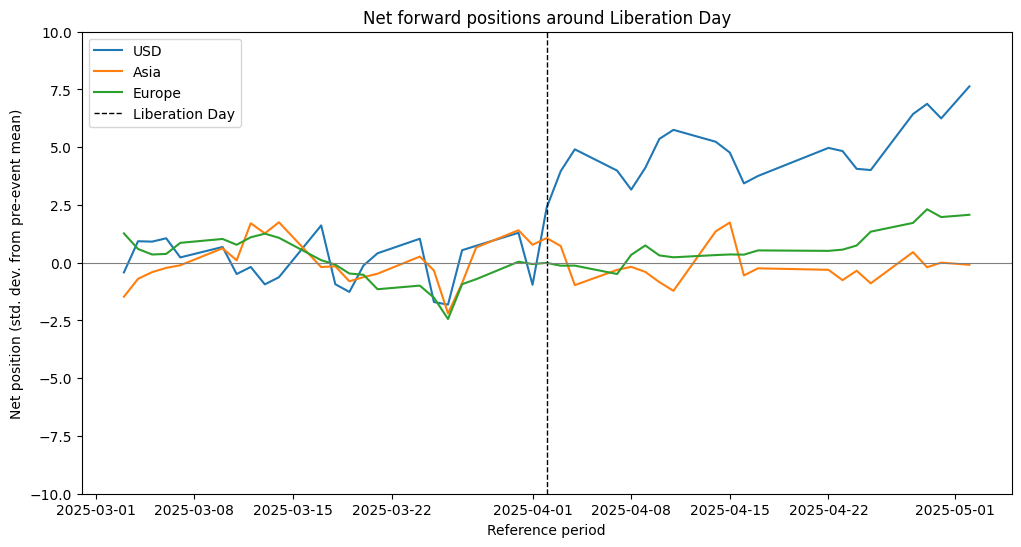

In [186]:
event = pd.Timestamp('2025-04-02')  # Liberation Day tariff announcement
base_window = 30                    # days before the event used as the baseline
plot_window = 30                    # days shown on each side of the event

net = es.pivot(index='reference_period', columns='grp', values='net_eur')
net.index = pd.to_datetime(net.index)
net = net.sort_index()

# standardise each series against its pre-event window (mean 0, sd 1) so the
# differently-sized series are comparable and all sit at the same level pre-event
pre = net[(net.index >= event - pd.Timedelta(days=base_window)) & (net.index < event)]
z = (net - pre.mean()) / pre.std()
z = z[(z.index >= event - pd.Timedelta(days=plot_window)) & (z.index <= event + pd.Timedelta(days=plot_window))]

fig, ax = plt.subplots(figsize=(12, 6))
for grp in ['USD', 'Asia', 'Europe']:
    ax.plot(z.index, z[grp], label=grp)
ax.axvline(event, color='black', linestyle='--', linewidth=1, label='Liberation Day')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Reference period')
ax.set_ylabel('Net position (std. dev. from pre-event mean)')
ax.set_title('Net forward positions around Liberation Day')
ax.set_ylim(-10, 10)
ax.legend()
plt.show()

In [106]:
# Flow = newly initiated forwards, each contract counted once at its first
# appearance (no UTI, so the contract key uses economic attributes)

start = '2024-04-26'  # REFIT period only (exclude the pre-2019 EMIR snapshots)

query = f"""

WITH legs AS (
    SELECT 'B' AS side, buyer_id AS cp1, seller_id AS cp2,
           reference_period, effective_date, maturity_date, currency1, currency2,
           CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'long' ELSE 'short' END AS direction,
           CASE WHEN currency1 = 'EUR' THEN currency2 ELSE currency1 END AS foreign_ccy
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND buyer_nfc = 1
      AND buyer_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND reference_period >= '{start}'
      AND reference_period NOT IN ('2025-04-18', '2025-04-21')
    UNION ALL
    SELECT 'S' AS side, buyer_id AS cp1, seller_id AS cp2,
           reference_period, effective_date, maturity_date, currency1, currency2,
           CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'short' ELSE 'long' END AS direction,
           CASE WHEN currency1 = 'EUR' THEN currency2 ELSE currency1 END AS foreign_ccy
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND seller_nfc = 1
      AND seller_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND reference_period >= '{start}'
      AND reference_period NOT IN ('2025-04-18', '2025-04-21')
),
tagged AS (
    SELECT effective_date, direction, notional_eur,
           CASE WHEN foreign_ccy = 'USD'        THEN 'USD'
                WHEN foreign_ccy IN ({asian})    THEN 'Asia'
                WHEN foreign_ccy IN ({european}) THEN 'Europe' END AS grp,
           ROW_NUMBER() OVER (PARTITION BY side, cp1, cp2, effective_date, maturity_date,
                                           currency1, currency2, notional_eur
                              ORDER BY reference_period) AS rn
    FROM legs
)
-- net (long - short) new forward notional per effective date and group
SELECT effective_date, grp,
       SUM(CASE WHEN direction = 'long' THEN notional_eur ELSE -notional_eur END) AS net_eur
FROM tagged
WHERE grp IS NOT NULL AND rn = 1
GROUP BY effective_date, grp
ORDER BY effective_date, grp

"""

flow = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_16344\507466237.py:55: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  flow = pd.read_sql_query(query, cnxn)


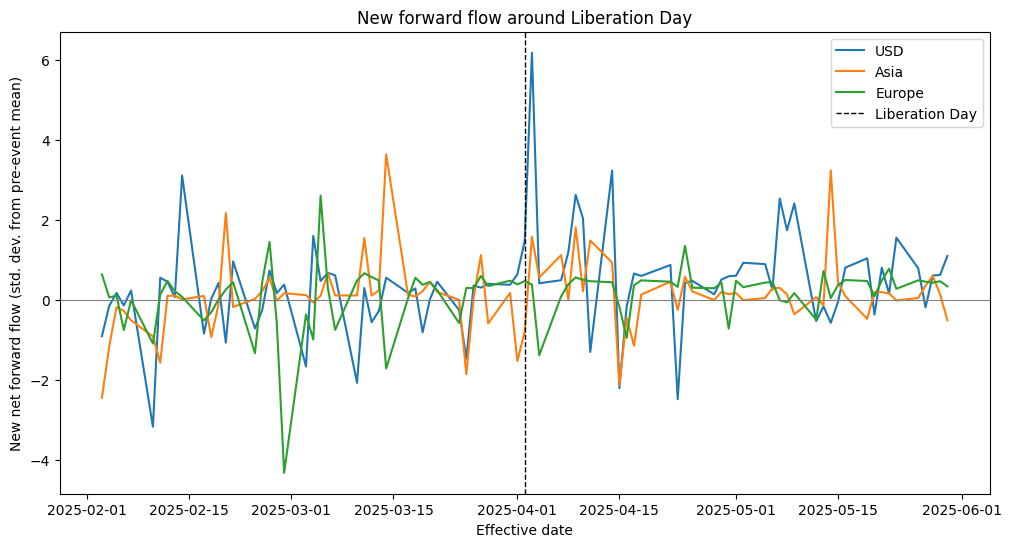

In [107]:
event = pd.Timestamp('2025-04-02')  # Liberation Day tariff announcement
base_window = 60                    # days before the event used as the baseline
plot_window = 60                    # days shown on each side of the event

net = flow.pivot(index='effective_date', columns='grp', values='net_eur')
net.index = pd.to_datetime(net.index)
net = net.sort_index().fillna(0)  # a day with no new contracts is zero flow, not missing

# standardise each series against its pre-event window (mean 0, sd 1)
pre = net[(net.index >= event - pd.Timedelta(days=base_window)) & (net.index < event)]
z = (net - pre.mean()) / pre.std()
z = z[(z.index >= event - pd.Timedelta(days=plot_window)) & (z.index <= event + pd.Timedelta(days=plot_window))]

fig, ax = plt.subplots(figsize=(12, 6))
for grp in ['USD', 'Asia', 'Europe']:
    ax.plot(z.index, z[grp], label=grp)
ax.axvline(event, color='black', linestyle='--', linewidth=1, label='Liberation Day')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Effective date')
ax.set_ylabel('New net forward flow (std. dev. from pre-event mean)')
ax.set_title('New forward flow around Liberation Day')
ax.legend()
plt.show()

In [ ]:
# Decomposition of the net outstanding positions above into their gross long
# and short legs (same filters and groups as the net query)

start = '2024-04-26'  # REFIT period only (exclude the pre-2019 EMIR snapshots)

query = f"""

WITH legs AS (
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'long' ELSE 'short' END AS direction,
           CASE WHEN currency1 = 'EUR' THEN currency2 ELSE currency1 END AS foreign_ccy
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND buyer_nfc = 1
      AND buyer_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND reference_period >= '{start}'
      AND reference_period NOT IN ('2025-04-18', '2025-04-21')
    UNION ALL
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'short' ELSE 'long' END AS direction,
           CASE WHEN currency1 = 'EUR' THEN currency2 ELSE currency1 END AS foreign_ccy
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND seller_nfc = 1
      AND seller_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND reference_period >= '{start}'
      AND reference_period NOT IN ('2025-04-18', '2025-04-21')
),
classified AS (
    SELECT reference_period, notional_eur, direction,
           CASE WHEN foreign_ccy = 'USD'        THEN 'USD'
                WHEN foreign_ccy IN ({asian})    THEN 'Asia'
                WHEN foreign_ccy IN ({european}) THEN 'Europe' END AS grp
    FROM legs
)
-- gross long and gross short outstanding notional per day and group (net = long - short)
SELECT reference_period, grp,
       SUM(CASE WHEN direction = 'long'  THEN notional_eur ELSE 0 END) AS long_eur,
       SUM(CASE WHEN direction = 'short' THEN notional_eur ELSE 0 END) AS short_eur
FROM classified
WHERE grp IS NOT NULL
GROUP BY reference_period, grp
ORDER BY reference_period, grp

"""

gross = pd.read_sql_query(query, cnxn)

In [ ]:
event = pd.Timestamp('2025-04-02')  # Liberation Day tariff announcement
base_window = 30                    # days before the event used as the baseline
plot_window = 30                    # days shown on each side of the event

longs = gross.pivot(index='reference_period', columns='grp', values='long_eur')
shorts = gross.pivot(index='reference_period', columns='grp', values='short_eur')
longs.index = pd.to_datetime(longs.index)
shorts.index = pd.to_datetime(shorts.index)
longs = longs.sort_index()
shorts = shorts.sort_index()

# deviations from the pre-event mean in EUR bn (not z-scores): within a group the
# two legs share a scale and the changes stay additive, so the panels show which
# leg drives the net series plotted above (net = long - short)
pre_long = longs[(longs.index >= event - pd.Timedelta(days=base_window)) & (longs.index < event)]
pre_short = shorts[(shorts.index >= event - pd.Timedelta(days=base_window)) & (shorts.index < event)]
d_long = (longs - pre_long.mean()) / 1e9
d_short = (shorts - pre_short.mean()) / 1e9
shown = (d_long.index >= event - pd.Timedelta(days=plot_window)) & (d_long.index <= event + pd.Timedelta(days=plot_window))
d_long, d_short = d_long[shown], d_short[shown]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True, constrained_layout=True)
for ax, grp in zip(axes, ['USD', 'Asia', 'Europe']):
    ax.plot(d_long.index, d_long[grp], label='Long')
    ax.plot(d_short.index, d_short[grp], label='Short')
    ax.plot(d_long.index, d_long[grp] - d_short[grp], color='grey', linestyle=':', label='Net (long - short)')
    ax.axvline(event, color='black', linestyle='--', linewidth=1, label='Liberation Day')
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.set_ylabel('Change vs pre-event mean (EUR bn)')
    ax.set_title(grp)
axes[0].legend()
axes[-1].set_xlabel('Reference period')
fig.suptitle('Net positions around Liberation Day, decomposed into long and short legs')
plt.show()

## Current account

In [2]:
# Outstanding long/short FX forward volumes of the (non-financial) entities, per day.
# Re-queried here so this chapter runs on its own (after the setup cell).
query = f"""

WITH legs AS (
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'long' ELSE 'short' END AS direction
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND buyer_nfc = 1
      AND buyer_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND (reference_period >= '2025-01-01' OR reference_period <= '2024-04-01')
    UNION ALL
    SELECT reference_period, CAST(notional_eur AS DOUBLE) AS notional_eur,
           CASE WHEN currency1 <> 'EUR' THEN 'short' ELSE 'long' END AS direction
    FROM lab_prj_emir_ecb.hermesf_fx
    WHERE contract_type = 'FORW' AND seller_nfc = 1
      AND seller_id NOT IN ({banks})
      AND notional_eur <= 1e11
      AND (currency1 = 'EUR' OR currency2 = 'EUR')
      AND (reference_period >= '2025-01-01' OR reference_period <= '2024-04-01')
)
SELECT
    reference_period,
    SUM(CASE WHEN direction = 'long'  THEN notional_eur ELSE 0 END) AS long_eur,
    SUM(CASE WHEN direction = 'short' THEN notional_eur ELSE 0 END) AS short_eur
FROM legs
GROUP BY reference_period
ORDER BY reference_period

"""

ts = pd.read_sql_query(query, cnxn)
ts['reference_period'] = pd.to_datetime(ts['reference_period'])
ts = ts.set_index('reference_period').sort_index()

C:\Users\hermesf\AppData\Local\Temp\ipykernel_11484\2871174984.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ts = pd.read_sql_query(query, cnxn)


In [146]:
ts = ts[(ts['long_eur'] > 70000000000) & (ts['short_eur'] > 130000000000)]

In [3]:
# Euro area current account balance (BPM6), monthly, calendar & seasonally adjusted, EUR mn.
# The ECB export holds one column per country; we take the euro area aggregate (composition I10).
ca_raw = pd.read_csv('ecb_current_account.csv')
ea_col = [c for c in ca_raw.columns if 'I10' in c][0]
ca = ca_raw[['DATE', ea_col]].dropna()
ca = ca.set_index(pd.PeriodIndex(pd.to_datetime(ca['DATE']), freq='M'))[ea_col] / 1e3  # EUR mn -> bn
ca = ca.rename('current_account')

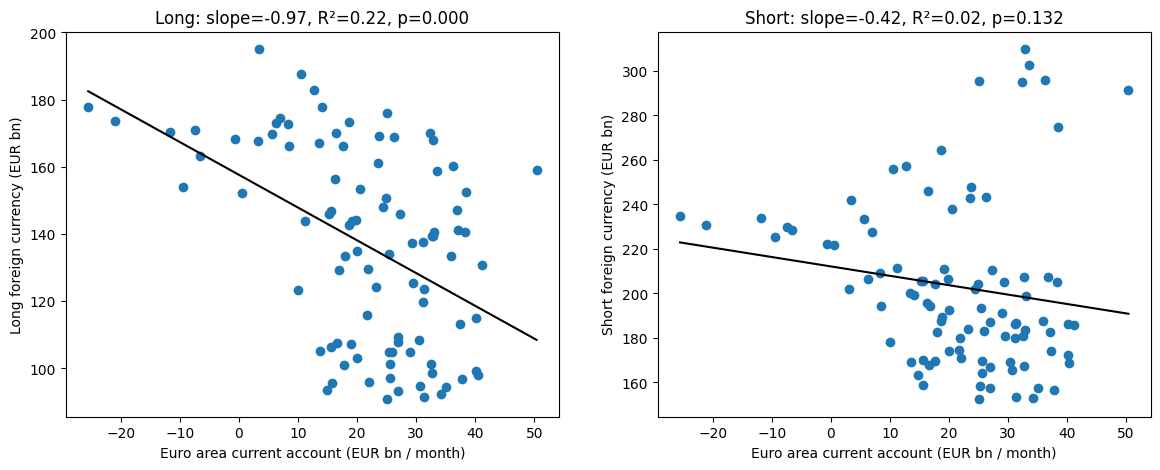

In [4]:
# frequency mismatch: daily outstanding stock -> monthly average, then merge with monthly CA
monthly = (ts[['long_eur', 'short_eur']] / 1e9).resample('M').mean()
monthly.index = monthly.index.to_period('M')
df = monthly.join(ca, how='inner').dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ['long_eur', 'short_eur'], ['Long', 'Short']):
    sl, ic, r, p, se = stats.linregress(df['current_account'], df[col])
    ax.scatter(df['current_account'], df[col])
    xs = np.array([df['current_account'].min(), df['current_account'].max()])
    ax.plot(xs, ic + sl * xs, color='black')
    ax.set_title(f'{label}: slope={sl:.2f}, R²={r ** 2:.2f}, p={p:.3f}')
    ax.set_xlabel('Euro area current account (EUR bn / month)')
    ax.set_ylabel(f'{label} foreign currency (EUR bn)')
plt.show()

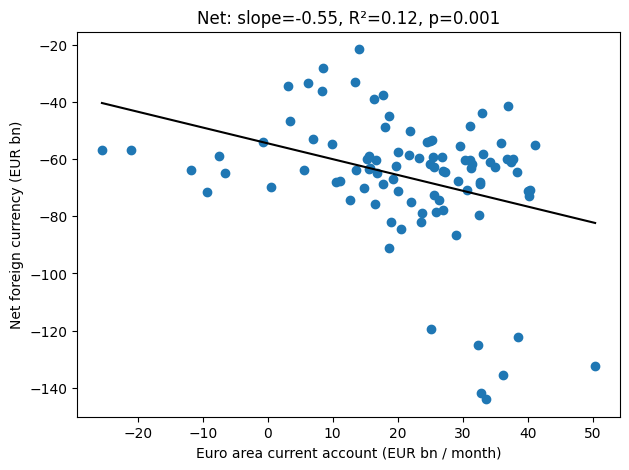

In [9]:
# net position (long - short = net long foreign currency) vs current account
net_fc = ((ts['long_eur'] - ts['short_eur']) / 1e9).resample('M').mean().rename('net')
net_fc.index = net_fc.index.to_period('M')
dfn = pd.concat([net_fc, ca], axis=1, join='inner').dropna()

sl, ic, r, p, se = stats.linregress(dfn['current_account'], dfn['net'])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dfn['current_account'], dfn['net'])
xs = np.array([dfn['current_account'].min(), dfn['current_account'].max()])
ax.plot(xs, ic + sl * xs, color='black')
ax.set_title(f'Net: slope={sl:.2f}, R²={r ** 2:.2f}, p={p:.3f}')
ax.set_xlabel('Euro area current account (EUR bn / month)')
ax.set_ylabel('Net foreign currency (EUR bn)')
plt.show()